# **Aggregation MD Directory Analysis Notebook**

This notebook provides a structured workflow for analyzing **Aggregation MD** simulations performed at different temperatures and deposition intervals. The analysis is carried out using modular Python scripts.

---

## Workflow Overview
1. **Load and Extract Data**  
   Retrieve simulation output files based on the specified temperature and deposition interval.

2. **Visualize System Configuration**  
   Generate static and dynamic visualizations of particle configurations, allowing for direct comparison across conditions.

3. **Heatmaps of Cluster Parameters**  
   Compare key cluster properties across different simulation settings, including:
   - **Orientational Order**
   - **Number of Neighbors**
   - **Radius of Gyration**
   - **Fractal Dimension**
   - **Anisotropy Ratio**

---

## Part 1: Load and Extract Data
Extract relevant variables and attributes from a selected simulation file. The file naming follows a structured format (e.g., *aggregated_0.15_2.5.bp*), where the numbers represent temperature and deposition interval.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import data_extraction
import visualization
import system_analysis

output_dir = "/home/hadis/selfassembly/run/particleOriented/march15_aggregationRun/outputs"
target_file = data_extraction.file_selection(output_dir, temperature=0.15, deposition_interval=2)

---

## Part 2: Visualize System Configuration
Plot particle configurations at a given simulation step to examine cluster formation. Exporting images using a systematic naming convention facilitates easy cross-comparison.


available steps:  4000 	choosed step:  -1


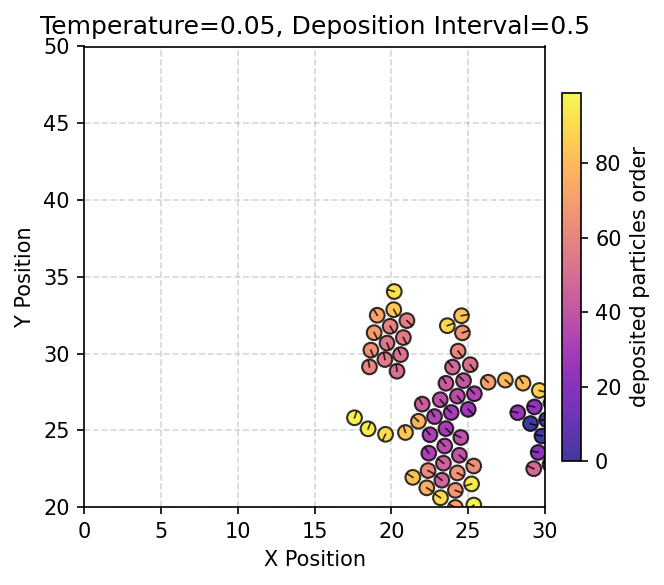

In [3]:
visualization.plot_configuration_aggregation(output_dir, .05, 0.5, step_target=-1, 
                                             x_limit=(0, 30), y_limit=(20, 50), save_fig=True, diameter=50)
# visualization.plot_configuration_aggregation(output_dir, .25, 9, step_target=-1, x_limit=(0, 30), y_limit=(20, 50), save_fig=True, diameter=50)

In [ ]:
visualization.animate_position_aggregation(output_dir, temperature=0.15, deposition_rate=0.5, frame_skip=1)

---

## Part 3: Heatmaps of Cluster Parameters
Compute and visualize key cluster properties across a range of **temperature (T)** and **deposition interval (dt)** values, helping to analyze cluster evolution and system behavior.


In [10]:
ranges = data_extraction.extract_ranges(output_dir)

temperatures = ranges ['temperatures']
deposition_rates = ranges ['deposition_rates']

Temperature range: 	0.05 .. 0.35
Deposition Rate range: 	0.5 .. 9.0


### **3-1. Orientational Order Parameter**  
   - Defined as: $\cos(2\Delta\phi)$
   - Measures the local alignment of particles.


In [11]:
order_matrix = data_extraction.extract_order_parameter_matrix(output_dir, temperatures, deposition_rates)

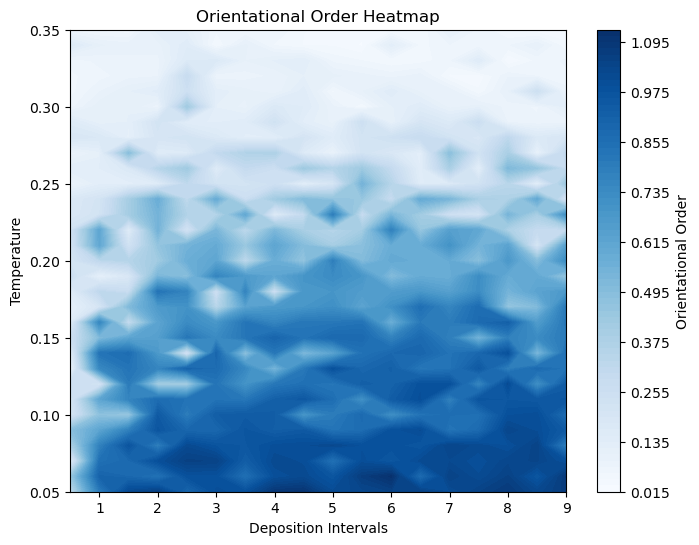

In [12]:
visualization.plot_parameter_heatmap(order_matrix, 'Orientational Order', temperatures, deposition_rates, cmap='Blues')

### **3-2. Number of Neighbors**  
   - Computes the average number of neighbors per particle.


In [ ]:
neighbors_matrix = data_extraction.extract_neighbors_number_matrix(output_dir, temperatures, deposition_rates)

In [ ]:
visualization.plot_parameter_heatmap(neighbors_matrix, 'Number of Neighbors', temperatures, deposition_rates, cmap='viridis')

### **3-3. Radius of Gyration (Rg)**  
   The **radius of gyration** quantifies the spatial distribution of particles within a cluster, indicating how compact or dispersed the structure is. It is given by:

   $$
   R_g = \sqrt{\frac{1}{N} \sum_{i=1}^{N} |\mathbf{r}_i - \mathbf{r}_{\text{CM}}|^2}
   $$

   where $N$ is the number of particles, $\mathbf{r}_i$ represents the position of each particle and $\mathbf{r}_{\text{CM}}$ is the center of mass.

   **Interpretation:**
   - **Larger $ R_g $** → More dispersed cluster.  
   - **Smaller $ R_g $** → More compact cluster.

In [ ]:
Rg_matrix = system_analysis.compute_parameter_matrix(output_dir, temperatures, deposition_rates, 'gyration radius')

In [ ]:
visualization.plot_parameter_heatmap(Rg_matrix, 'Radius of Gyration', temperatures, deposition_rates, cmap='Purples')

### **3-4. Convex Hull Area (Spatial Spread)**  
The **convex hull area** represents the minimum convex polygon encompassing all particles in a cluster. This metric quantifies the **spatial distribution** and **overall footprint** of molecular arrangements.

#### **Formula:**
$$
\text{Convex Hull Area} = \text{Area of minimum enclosing convex polygon}
$$

#### **Interpretation:**
- **Large values** → Particles are distributed over a wider spatial region  
- **Small values** → Particles are tightly packed in a confined area  
- **Rapid area changes** → Indicate structural reorganization during simulation  
- **Stable values** → Suggest equilibrium spatial distribution  

#### **Comparative Analysis:**
1. Combine with cluster density metrics for complete spatial understanding  
2. Compare with gyration radius (3-2) to differentiate between linear vs. planar spreading  
3. Use alongside fractal dimension (3-3) to identify branching patterns  

#### **Normalization Consideration:**
Results should be interpreted relative to:  
- System size constraints  
- Total particle count in cluster  
- Simulation box dimensions  

In [ ]:
perimeter_area_matrix = system_analysis.compute_parameter_matrix(output_dir, temperatures, deposition_rates, 'convexHull')

In [ ]:
visualization.plot_parameter_heatmap(perimeter_area_matrix, 'ConvexHull area', temperatures, deposition_rates, cmap='plasma')

### **3-5. Cluster Perimeter / Area Ratio (Compactness)**  
The **compactness** of a cluster is determined by the ratio of its perimeter to its area. This measure helps differentiate between **dense, compact clusters** and **branched, loosely connected structures**.

#### **Formula:**
$$
C = \frac{\text{Perimeter}}{\text{Area}}
$$

#### **Interpretation:**
- **Low $C$ values** → Dense, compact clusters  
- **High $C$ values** → Loose, branched structures  


#### **3-x. Fractal Dimension (Df)**  //Not now, inaccurate for small systems
The **fractal dimension** quantifies the complexity and self-similarity of a cluster. It provides insight into how space-filling or branched the structure is. One common way to estimate $D_f$ is through **mass-radius scaling**:

$$
N(r) \sim r^{D_f}
$$

where $N(r)$ is the number of particles within a radius $r$ from the cluster center.

**Interpretation:**  
- **Higher $D_f$** → Dense, space-filling clusters (compact growth).  
- **Lower $D_f$** → Branched, dendritic structures (DLA growth).  